# Binary Classification — Logistic Regression from Scratch

Gradient descent logistic regression implemented without scikit-learn, on a synthetic dataset generated from a known decision boundary (`true_w = [2.0, -3.0]`, `true_b = 0.5`), so the parameters gradient descent recovers can be checked directly against the ground truth.

**Model:** $f(\mathbf{x}) = \sigma(\mathbf{w}\cdot\mathbf{x} + b) = \dfrac{1}{1+e^{-(\mathbf{w}\cdot\mathbf{x}+b)}}$
**Cost:** $J = -\frac{1}{m}\sum \left[y\log(f(x)) + (1-y)\log(1-f(x))\right]$
**Gradients:** $\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum(f(x)-y)x_j$, $\frac{\partial J}{\partial b} = \frac{1}{m}\sum(f(x)-y)$
**Update:** $w \mathrel{-}= \alpha\frac{\partial J}{\partial w}$, $b \mathrel{-}= \alpha\frac{\partial J}{\partial b}$

In [67]:
import numpy as np
import seaborn as sns
import pandas as pd

Standard imports: `numpy` for the math, `seaborn` for the plots. `pandas` is imported for parity with the regression notebook but unused here, since the dataset is generated directly as numpy arrays.

In [93]:
rng = np.random.default_rng(42)
n = 500
X = rng.normal(0, 1, size=(n, 2))
true_w = np.array([2.0, -3.0])
true_b = 0.5
z = X @ true_w + true_b
p = 1 / (1 + np.exp(-z))
y = (rng.random(n) < p).astype(int)

Generates a synthetic binary classification dataset: 500 examples with two standard-normal features `X`, a true decision boundary `true_w = [2.0, -3.0]` and `true_b = 0.5`, and labels `y` sampled as Bernoulli draws from the true sigmoid probability `p = σ(X·true_w + true_b)` — so the ground truth is known and the weights gradient descent recovers can be checked against it.

In [100]:
y = y.reshape(-1, 1)

Reshapes `y` into a column vector, matching the `(m, 1)` shape produced by `Calculate_fwx` below.

In [70]:
def Calculate_fwx(X, w, b):
    return np.sum(w*X, axis=1, keepdims=True) + b

**Model function `Calculate_fwx`:** the linear part $z = \mathbf{w}\cdot\mathbf{x} + b$, computed for every example at once via broadcasting (`w*X` then summed across features).

In [71]:
def Calculate_sigmoid(X, w, b):
    fwx = Calculate_fwx(X, w, b)
    sigmoid = 1 / (1 + np.exp(-fwx))
    return sigmoid

**`Calculate_sigmoid`:** applies the sigmoid $\sigma(z) = \dfrac{1}{1+e^{-z}}$ to `Calculate_fwx`'s output, squashing the linear score into a probability in $(0,1)$.

In [72]:
def Calculate_loss(X, w, b, y):
    m = X.shape[0]
    sigmoid = Calculate_sigmoid(X, w, b)
    loss = (y)*np.log(sigmoid) + ((1-y) * np.log(1 - sigmoid))
    cost = np.sum(loss) / -m
    return cost

**Cost function `Calculate_loss`:** binary cross-entropy, averaged over all examples and negated — the quantity gradient descent minimizes.

In [73]:
def Calculate_gradient(X, w, b, y):
    m = X.shape[0]
    sigmoid = Calculate_sigmoid(X, w, b)
    error = sigmoid - y

    dj_db = np.sum(error) / m
    dj_dw = np.sum(error * X, axis=0, keepdims=True) / m

    return dj_dw, dj_db

**`Calculate_gradient`:** returns both $\frac{\partial J}{\partial w}$ (a vector, one entry per feature) and $\frac{\partial J}{\partial b}$. The formula is identical to linear regression's — only `error = sigmoid - y` differs, since the sigmoid-squashed prediction replaces the raw linear one.

In [74]:
def Gradient_descent(X, y, alpha, num_iters):
    m = X.shape[0]
    cost_history = []

    w = np.zeros((1, X.shape[1]))
    b = 0

    for i in range(num_iters):

        dj_dw, dj_db = Calculate_gradient(X, w, b, y)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if(i%10 == 0):
            cost = Calculate_loss(X, w, b, y)
            cost_history.append(cost)

    return w, b, cost_history

**`Gradient_descent`:** the training loop. `w` starts as a zero vector sized to `X`'s number of features, so it adapts to however many columns `X` has. Each iteration updates `w` and `b` together, and the loss is logged to `cost_history` every 10 iterations.

In [129]:
w, b, cost_history = Gradient_descent(X, y, 0.1, 10000)
print(w, b)

[[ 2.00506285 -2.97150628]] 0.46850096427841026


Trains for 10,000 iterations at `alpha=0.1`, then prints the learned `w` and `b` — they land close to the true `[2.0, -3.0]` and `0.5` used to generate the data, confirming the implementation works.

<Axes: >

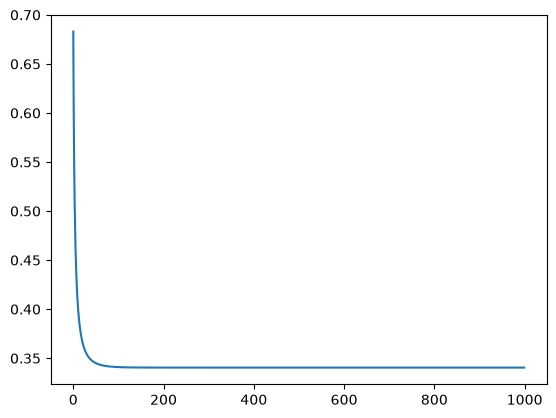

In [130]:
sns.lineplot(x=np.arange(1000), y=cost_history)

Plots `cost_history` over training — since cost is only logged every 10 iterations, the x-axis (0–999) is measured in logged steps, not raw iterations. It should drop steeply at first and flatten out as gradient descent converges toward the minimum.

---
*This documentation was written by AI (Claude); all the modeling code above is my own.*